# Micro Proyecto 2: Modelos avanzados para el Procesamiento de Lenguaje Natural

**Objetivo:** Creación de un modelo GPT -0 y Fine-tunning con base en Shakespeare.

# **1. GPT desde 0**

## Instalación de librerías

In [1]:
!pip install transformers datasets accelerate -q

import torch
import torch.nn as nn
from torch.nn import functional as F

## Hiperparámetros a utilizar

In [2]:
batch_size = 32
block_size = 128
max_iters = 2000
eval_interval = 200
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 100
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.2
print(device)

cuda


## Import de datos y verificación del dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
dataset_path = '/content/drive/MyDrive/Andes/202612/NLP2/Microproyecto2'
os.makedirs(dataset_path, exist_ok=True)
os.chdir(dataset_path)
os.getcwd()

'/content/drive/MyDrive/Andes/202612/NLP2/Microproyecto2'

In [5]:
with open('input-2-.txt', 'r', encoding='utf-8') as f:
    text = f.read()
print(f"Dataset: {len(text):,} caracteres")

Dataset: 1,115,394 caracteres


## Split del dataset

In [6]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
vocab_size = tokenizer.vocab_size  # 50257

encode = lambda s: tokenizer.encode(s)
decode = lambda l: tokenizer.decode(l)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


In [7]:
print(f"Tokens de validación:    {len(val_data):,}")
print(f"Tokens de entrenamiento: {len(train_data):,}")
print(f"Vocab size: {vocab_size}")

Tokens de validación:    33,803
Tokens de entrenamiento: 304,222
Vocab size: 50257


In [8]:
def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

## Modelo GPT

In [9]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * C**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

## Instancia y loop de train

In [10]:
model_scratch = GPTLanguageModel().to(device)
optimizer = torch.optim.AdamW(model_scratch.parameters(), lr=learning_rate)

scratch_train_losses = []
scratch_val_losses = []
scratch_eval_steps = []

for iter in range(max_iters):
    if iter % eval_interval == 0 or iter == max_iters - 1:
        model_scratch.eval()
        losses = {'train': 0, 'val': 0}
        with torch.no_grad():
            for split in ['train', 'val']:
                losses_arr = torch.zeros(eval_iters)
                for k in range(eval_iters):
                    X, Y = get_batch(split)
                    logits, loss = model_scratch(X, Y)
                    losses_arr[k] = loss.item()
                losses[split] = losses_arr.mean()
        print(f"Paso {iter}: loss entrenamiento {losses['train']:.4f}, loss validación {losses['val']:.4f}")
        scratch_train_losses.append(losses['train'].item())
        scratch_val_losses.append(losses['val'].item())
        scratch_eval_steps.append(iter)
        model_scratch.train()

    xb, yb = get_batch('train')
    logits, loss = model_scratch(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

Paso 0: loss entrenamiento 10.9975, loss validación 10.9924
Paso 200: loss entrenamiento 5.9989, loss validación 6.1040
Paso 400: loss entrenamiento 5.4826, loss validación 5.7188
Paso 600: loss entrenamiento 5.0612, loss validación 5.4605
Paso 800: loss entrenamiento 4.8078, loss validación 5.2453
Paso 1000: loss entrenamiento 4.6195, loss validación 5.1387
Paso 1200: loss entrenamiento 4.4642, loss validación 5.0166
Paso 1400: loss entrenamiento 4.3695, loss validación 4.9752
Paso 1600: loss entrenamiento 4.2452, loss validación 4.9043
Paso 1800: loss entrenamiento 4.1580, loss validación 4.8684
Paso 1999: loss entrenamiento 4.0622, loss validación 4.8402


In [11]:
torch.save(model_scratch.state_dict(), 'gpt_desde_cero_checkpoint.pth')

##Generación de 3 ejemplos

In [12]:
model_scratch.eval()
for i in range(3):
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated_text = decode(model_scratch.generate(context, max_new_tokens=150)[0].tolist())
    print(f"\n--- Ejemplo {i+1} del GPT desde 0 ---")
    print(generated_text)


--- Ejemplo 1 del GPT desde 0 ---
!

NORTHUMER:
For upon Saint allowance him hence.

DUCHESS OF YORK:
My lord that so duke is your boy; but this te to death,
As much assailantser cruel fled to aller itge,
you dry the execution note us that I die of damned to meet
By the scene us, and tender : it is the air,
And make it cut; he intelligence him tempted a fearful prisoner unto his prince,
The present should she's unrealful less
Wouldigator whose wife of great strength.
How, the triumph, but stronger, for this night, fear it is it,
it and into justice of limit through the plate
And follow to part

--- Ejemplo 2 del GPT desde 0 ---
!
Wea' on God's respected! women; for that'st thou,
To men with thy hand!
For God defend thee, an ag Menen and cog,
The steed? that wouldst thou go, the time, our redress of thy mind!
And, thou this thy government, dropsers, begins,
And Iawks Fortune, with her law thy suspicion,
Thy slarer that thy soul acquaint thy pity.

Clown:
A love thee, set my son can com

#**2. Fine-tunning de GPT - 2**

## Import de librerías

In [13]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling, pipeline
from datasets import Dataset

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model_gpt2 = GPT2LMHeadModel.from_pretrained('gpt2').to(device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## Carga de datos

In [14]:
tokenizer.pad_token = tokenizer.eos_token

tokenized_text = tokenizer(text, return_attention_mask=False)

raw_datasets = Dataset.from_dict({"text": [tokenized_text["input_ids"]]})

Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


In [15]:
def group_texts(examples):
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])
    total_length = (total_length // block_size) * block_size
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    result["labels"] = result["text"].copy()
    return result

processed_datasets = raw_datasets.map(
    group_texts,
    batched=True,
    num_proc=1,
    remove_columns=raw_datasets.column_names,
)

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

In [16]:
processed_datasets = processed_datasets.rename_column("text", "input_ids")
train_test_split = processed_datasets.train_test_split(test_size=0.2)
train_dataset = train_test_split['train']
val_dataset = train_test_split['test']

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Training dataset size: 2112
Validation dataset size: 528


## Trainer

In [17]:
training_args = TrainingArguments(
    output_dir='./gpt2_finetuned_checkpoint',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    save_steps=500,
    save_total_limit=2,
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model_gpt2,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

## Train

In [18]:
trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
100,3.804897,3.529522
200,3.544688,3.458202
300,3.426418,3.428838
400,3.356020,3.413247
500,3.319124,3.405621
600,3.264927,3.398437


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=660, training_loss=3.4354073264382103, metrics={'train_runtime': 515.4475, 'train_samples_per_second': 20.487, 'train_steps_per_second': 1.28, 'total_flos': 689810964480000.0, 'train_loss': 3.4354073264382103, 'epoch': 5.0})

In [19]:
trainer.save_model('./gpt2_finetuned_final')
tokenizer.save_pretrained('./gpt2_finetuned_final')
torch.save(model_gpt2.state_dict(), 'gpt2_finetuned_checkpoint.pth')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Generación de 3 ejemplos

In [20]:
def generate_gpt2(model, tokenizer, prompt, max_new_tokens=150):
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(input_ids[:, -block_size:])
            logits = outputs.logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_token], dim=1)
    return tokenizer.decode(input_ids[0].tolist())

In [21]:
for i in range(3):
    prompt = "CORIOLANUS:\n"
    generated = generate_gpt2(model_gpt2, tokenizer, prompt, max_new_tokens=150)
    print(f"\n--- Ejemplo {i+1} (GPT-2) ---")
    print(generated)


--- Ejemplo 1 (GPT-2) ---
CORIOLANUS:
When is the sweets of these happy days to come?

MATHEMATIS:
Three days: if to be: but until he is.

CORIOLANUS:
Life is given place and beauty's nativity begins:
Strike me more than at the all of screen between.

MATHEMATIS:
Wherefore, old friends, what wish is there or what duty
Please all that you have thus far here?

CORIOLANUS:
Let us say our heart
Received no allurement within this room, nor
yet function instead in penury, for most noble
cases too call our heads: party, friends.
Give me a little more

--- Ejemplo 2 (GPT-2) ---
CORIOLANUS:
That the mind of the king
Would choose me worthy to be that guiltless villain
To lurk in the bosom of slanders in his throat:
Yet this sovereign, that sighing tongue,
Make amends your words; and put my on my nose.
Therefore do join my good advice to your speeches;
Servant:
What say you of me? no, of myself; the further we the pper we stretch,
And the calmer with moneythink a dream, the further we that frown

# **3. Análisis Comparativo**

| Modelo | Arquitectura | Vocab | Parámetros aprox. | Mínimo val loss |
|--------|-------------|-------|-------------------|-----------------|
| GPT desde 0 | 4 capas, 4 heads, embd=128 | 50,257 | ~14M | **4.8402** |
| GPT-2 fine-tuning | 12 capas, 12 heads, embd=768 | 50,257 | 124M | **3.3984** |

La diferencia en pérdida de validación (~1.44 puntos) se traduce en una diferencia de perplexidad de aproximadamente 4× (e^4.84 ≈ 126 vs e^3.40 ≈ 30), lo que refleja la ventaja del transfer learning.

---

**GPT desde 0:** El modelo converge desde una pérdida inicial de 10.98 (≈ log(50257), pérdida de un clasificador uniforme sobre el vocabulario) hasta 4.06 de train y 4.84 de validación. El gap de ~0.78 entre ambas curvas indica sobreajuste moderado: el modelo de 14M de parámetros tiene capacidad limitada para aprender las estructuras del inglés shakesperiano desde cero con solo 304K tokens de entrenamiento. El dropout (0.2) frena el sobreajuste pero no lo elimina. El texto generado captura la estructura dramática (nombres de personajes, diálogos en verso), aunque la coherencia semántica entre frases es inconsistente.

**GPT-2 fine-tuning:** El val loss final (3.40) es inferior al training loss promedio durante el entrenamiento (3.44), lo que confirma que no hay sobreajuste — el modelo generaliza bien. Esto se debe a que GPT-2 ya tiene conocimiento robusto del inglés adquirido en pre-entrenamiento; el fine-tuning solo ajusta ese conocimiento al estilo shakesperiano. El texto generado muestra diálogos multi-personaje coherentes con estructura dramática correcta, aunque ocasionalmente inventa nombres de personajes no pertenecientes al corpus (e.g., "MATHEMATIS").

**Conclusión:** El fine-tuning de GPT-2 supera claramente al modelo desde cero tanto en métricas como en calidad del texto. Para una tarea de adaptación de dominio con un corpus pequeño (~300K tokens), partir de pesos pre-entrenados es la estrategia correcta.

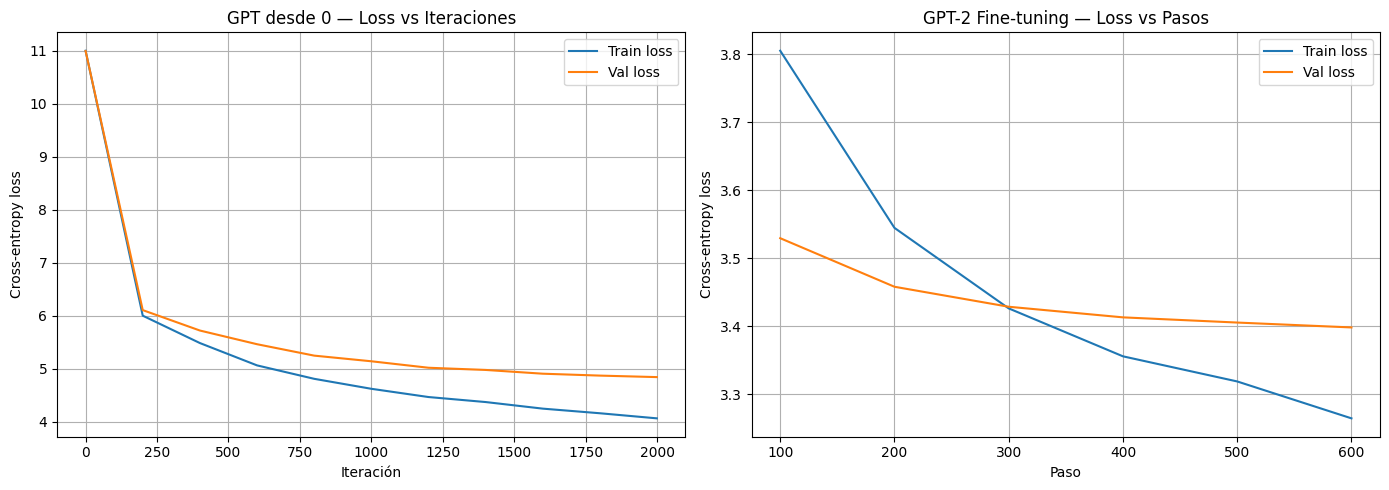

GPT desde 0       — mínimo val loss: 4.8402
GPT-2 fine-tuning — mínimo val loss: 3.3984


In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(scratch_eval_steps, scratch_train_losses, label='Train loss')
axes[0].plot(scratch_eval_steps, scratch_val_losses, label='Val loss')
axes[0].set_title('GPT desde 0 — Loss vs Iteraciones')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()
axes[0].grid(True)

log_history = trainer.state.log_history
gpt2_eval_steps = [e['step'] for e in log_history if 'eval_loss' in e]
gpt2_eval_loss  = [e['eval_loss'] for e in log_history if 'eval_loss' in e]
gpt2_train_steps = [e['step'] for e in log_history if 'loss' in e and 'eval_loss' not in e]
gpt2_train_loss  = [e['loss'] for e in log_history if 'loss' in e and 'eval_loss' not in e]

axes[1].plot(gpt2_train_steps, gpt2_train_loss, label='Train loss')
axes[1].plot(gpt2_eval_steps, gpt2_eval_loss, label='Val loss')
axes[1].set_title('GPT-2 Fine-tuning — Loss vs Pasos')
axes[1].set_xlabel('Paso')
axes[1].set_ylabel('Cross-entropy loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150)
plt.show()

min_scratch_val = min(scratch_val_losses)
min_gpt2_val    = min(gpt2_eval_loss) if gpt2_eval_loss else float('nan')
print(f"GPT desde 0       — mínimo val loss: {min_scratch_val:.4f}")
print(f"GPT-2 fine-tuning — mínimo val loss: {min_gpt2_val:.4f}")